# Notebook 02: Embeddings and Data Preparation

Components:
- Character-level tokenization (no external libraries)
- Learnable embedding layer with backpropagation
- Sinusoidal positional encoding
- Data loading and batching for training

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## 1. Character-Level Tokenization

Instead of using a pre-trained tokenizer (like BPE), we map each unique character to an integer. This keeps things simple and truly "from scratch".

In [2]:
# Load training data
with open('../data/input.txt', 'r') as f:
    text = f.read()

print(f"Text length: {len(text)} characters")
print(f"First 200 characters:\n{text[:200]}")

Text length: 10160 characters
First 200 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [3]:
# Build character vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

# Create mappings
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode/decode functions
def encode(s):
    """Convert string to list of integers."""
    return [char_to_idx[c] for c in s]

def decode(indices):
    """Convert list of integers to string."""
    return ''.join([idx_to_char[i] for i in indices])

# Test
test_str = "Hello"
encoded = encode(test_str)
decoded = decode(encoded)
print(f"\nEncode '{test_str}' -> {encoded}")
print(f"Decode {encoded} -> '{decoded}'")

# Encode entire dataset
data = np.array(encode(text), dtype=np.int64)
print(f"\nDataset shape: {data.shape}")
print(f"First 20 tokens: {data[:20]}")

Vocabulary size: 58
Characters: 
 !',-.:;?ABCDEFGHIJLMNOPRSTUVWYabcdefghijklmnopqrstuvwxyz

Encode 'Hello' -> [17, 36, 43, 43, 46]
Decode [17, 36, 43, 43, 46] -> 'Hello'

Dataset shape: (10160,)
First 20 tokens: [15 40 49 50 51  1 12 40 51 40 57 36 45  7  0 11 36 37 46 49]


## 2. Embedding Layer

An embedding layer is essentially a lookup table: each token index maps to a learnable vector.

**Forward**: Select rows from the embedding matrix.  
**Backward**: Accumulate gradients for the selected rows.

In [4]:
class Embedding:
    """Learnable embedding lookup table."""
    
    def __init__(self, vocab_size, d_model):
        self.W = np.random.randn(vocab_size, d_model) * 0.02
        self.dW = None
        self.indices = None
        self.vocab_size = vocab_size
    
    def forward(self, indices):
        """Look up embeddings for given token indices.
        
        Args:
            indices: integer array of shape (batch, seq_len)
        Returns:
            embeddings of shape (batch, seq_len, d_model)
        """
        self.indices = indices
        return self.W[indices]
    
    def backward(self, dout):
        """Accumulate gradients for embedded tokens.
        
        Args:
            dout: gradient of shape (batch, seq_len, d_model)
        """
        self.dW = np.zeros_like(self.W)
        np.add.at(self.dW, self.indices, dout)

# Test embedding
d_model = 64
emb = Embedding(vocab_size, d_model)

# Create a small batch
batch_indices = np.array([data[:8], data[8:16]])  # (2, 8)
embedded = emb.forward(batch_indices)
print(f"Input indices shape: {batch_indices.shape}")
print(f"Embedded shape:      {embedded.shape}")
print(f"\nFirst token embedding (first 8 dims): {embedded[0, 0, :8]}")

Input indices shape: (2, 8)
Embedded shape:      (2, 8, 64)

First token embedding (first 8 dims): [ 0.01285446  0.02658305  0.00393042  0.01418008 -0.00179471  0.02880234
 -0.01352785  0.03601881]


## 3. Sinusoidal Positional Encoding

Since attention has no built-in notion of position, we add positional information using sinusoidal encoding (from the original "Attention is All You Need" paper):

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

This is **not learned**: it's a fixed encoding based on position.

Positional encoding shape: (32, 64)


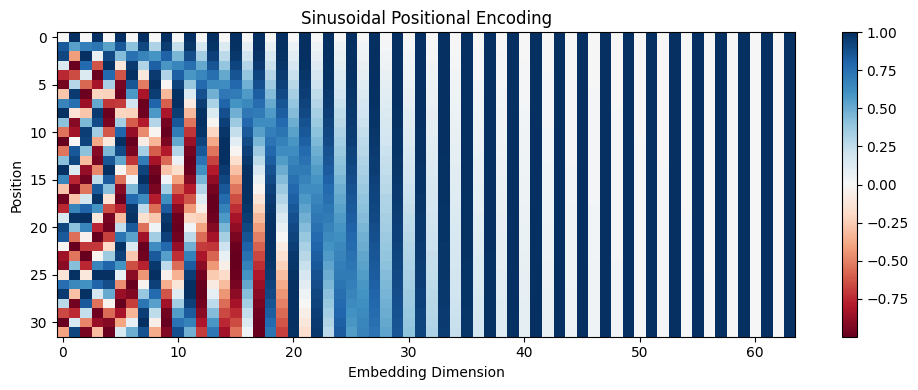

In [5]:
def get_positional_encoding(max_seq_len, d_model):
    """Generate sinusoidal positional encoding.
    
    Returns:
        pe: array of shape (max_seq_len, d_model)
    """
    pe = np.zeros((max_seq_len, d_model))
    position = np.arange(max_seq_len)[:, np.newaxis]  # (max_seq_len, 1)
    
    # Compute the division term
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    
    pe[:, 0::2] = np.sin(position * div_term)  # even indices
    pe[:, 1::2] = np.cos(position * div_term)  # odd indices
    
    return pe

# Generate and visualize
max_seq_len = 32
pe = get_positional_encoding(max_seq_len, d_model)
print(f"Positional encoding shape: {pe.shape}")

plt.figure(figsize=(10, 4))
plt.imshow(pe, aspect='auto', cmap='RdBu')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Sinusoidal Positional Encoding')
plt.colorbar()
plt.tight_layout()
plt.show()

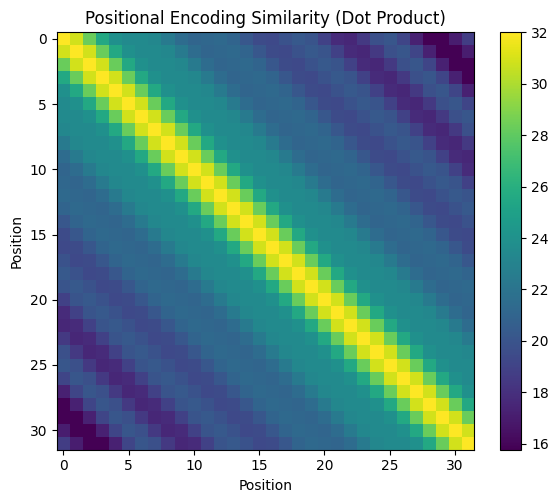

Nearby positions have higher similarity (brighter on diagonal).


In [6]:
# Show how positional encoding captures relative distances
# Similar positions have similar encodings (high dot product)
similarity = pe @ pe.T  # (max_seq_len, max_seq_len)

plt.figure(figsize=(6, 5))
plt.imshow(similarity, cmap='viridis')
plt.xlabel('Position')
plt.ylabel('Position')
plt.title('Positional Encoding Similarity (Dot Product)')
plt.colorbar()
plt.tight_layout()
plt.show()
print("Nearby positions have higher similarity (brighter on diagonal).")

## 4. Data Preparation

For training, we need to create input-target pairs:
- **Input**: a sequence of characters `[c1, c2, ..., cn]`
- **Target**: the next character for each position `[c2, c3, ..., cn+1]`

We split the data into random batches of fixed-length sequences.

In [7]:
def get_batch(data, batch_size, seq_len):
    """Get a random batch of input-target pairs.
    
    Args:
        data: 1D array of token indices
        batch_size: number of sequences per batch
        seq_len: length of each sequence
    
    Returns:
        x: input sequences, shape (batch_size, seq_len)
        y: target sequences, shape (batch_size, seq_len)
    """
    # Random starting positions
    max_start = len(data) - seq_len - 1
    starts = np.random.randint(0, max_start, size=batch_size)
    
    x = np.array([data[s:s+seq_len] for s in starts])
    y = np.array([data[s+1:s+seq_len+1] for s in starts])
    
    return x, y

# Test batch generation
batch_size = 4
seq_len = 32
x_batch, y_batch = get_batch(data, batch_size, seq_len)

print(f"Input batch shape:  {x_batch.shape}")
print(f"Target batch shape: {y_batch.shape}")

# Show first sequence
print(f"\nInput:  '{decode(x_batch[0])}'")
print(f"Target: '{decode(y_batch[0])}'")
print("\nNotice: target is shifted by 1 character (next-char prediction).")

Input batch shape:  (4, 32)
Target batch shape: (4, 32)

Input:  'y, these are almost thoroughly p'
Target: ', these are almost thoroughly pe'

Notice: target is shifted by 1 character (next-char prediction).


## 5. Putting It Together: Embed + Position

The input to a transformer block is: `Embedding(tokens) + PositionalEncoding`

In [8]:
# Full input pipeline
emb = Embedding(vocab_size, d_model)
pe = get_positional_encoding(max_seq_len, d_model)

x_batch, y_batch = get_batch(data, batch_size=4, seq_len=32)

# Embed tokens and add positional encoding
x_emb = emb.forward(x_batch)  # (batch, seq_len, d_model)
x_input = x_emb + pe[:x_batch.shape[1]]  # broadcast PE over batch

print(f"Token indices:     {x_batch.shape}")
print(f"After embedding:   {x_emb.shape}")
print(f"After + position:  {x_input.shape}")
print(f"\nThis tensor is ready to be fed into the transformer blocks!")

Token indices:     (4, 32)
After embedding:   (4, 32, 64)
After + position:  (4, 32, 64)

This tensor is ready to be fed into the transformer blocks!


## Summary

We've built:
- **Character tokenizer**: maps characters to integers and back
- **Embedding layer**: learnable lookup table with backprop
- **Positional encoding**: sinusoidal, captures position information
- **Data pipeline**: random batches of input-target pairs

Next notebook: **Self-Attention**, the core mechanism of transformers.